# Lab 3: Biological Data, Databases & Protein Alignment Scoring Matrices

## Learning goals
- Set up and use the shared `bio2` conda environment on the Luddy silo machine.
- Parse and validate FASTA records with Biopython.
- Retrieve metadata and sequences through NCBI Entrez and UniProt REST APIs.
- Understand scoring matrices (PAM and BLOSUM)

## Part 0 - Introduction of modules
Learn/review important modules using this [notebook](https://github.com/mgtools/Bio2/blob/main/notebooks/python-part2-mai.ipynb).
Practice using some of the mentioned modules (pandas, matplotlib) below. 

### NumPy
**NumPy** is a library for working with numerical data and arrays efficiently.

In [ ]:
import numpy as np

lengths = np.array([120, 250, 180, 310])

print("Average:", np.mean(lengths))
print("Longest:", np.max(lengths))
print("Lengths > 200:", lengths[lengths > 200])

### Pandas
**Pandas** is a library for organizing and analyzing tabular data using DataFrames.

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "gene": ["geneA", "geneB", "geneC"],
    "length": [120, 250, 180],
    "gc_percent": [45.2, 61.3, 52.8]
})

display(df)
display(df[df["gc_percent"] > 50])

### Matplotlib
**Matplotlib** is a library for creating plots and visualizing data.

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df["gene"], df["length"])
plt.xlabel("Gene")
plt.ylabel("Length (bp)")
plt.title("Gene Lengths")
plt.show()

## Part 1 — Environment Setup

### The `bio2` conda environment

A shared conda environment (`bio2`) has been created on the Luddy silo machine at  
`/nobackup/yye/Bio2/miniconda3/envs/bio2`.

To activate bio2 on silo, here are the options:

**Option A — VS Code**
1. Remote-connect to silo via VS Code.
2. Clone this notebook to your personal folder on silo.
3. Open the Command Palette → **Python: Select Interpreter** and set  
   `/nobackup/yye/Bio2/miniconda3/envs/bio2/bin/python` as the interpreter.

Optional: you may configure VS Code to automatically set the environment:
* In your project root folder, open (or create) .vscode/settings.json file.
* Add the python.defaultInterpreterPath setting pointing to shared path:

"python.defaultInterpreterPath": "/nobackup/yye/Bio2/miniconda3/envs/bio2/bin/python"

**Option B — Command line (init+activate)**
```bash
conda init /nobackup/yye/Bio2/miniconda3/bin/conda
```
If conda init ... doesn't work, try the following,
```bash
/nobackup/yye/Bio2/miniconda3/bin/conda init bash
```
When this step is done, you can activate bio2 as following,
```bash
conda activate bio2
```

**Plan B — Google Colab or run VS Code locally** (fallback if silo is unavailable or you cannot make it work for you)  
Run the install cell below, then proceed normally.

In [31]:
# Run once on Colab or a fresh environment — skip if bio2 is already active
# %pip install -q biopython numpy matplotlib pandas requests

In [32]:
from io import StringIO
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests

from Bio import Align, Entrez, SeqIO
from Bio.Align import substitution_matrices
from Bio.Seq import Seq
from Bio.SeqUtils import gc_fraction

print("All imports successful ✓")

All imports successful ✓


## Part 2: Basic IO using BioPython

In [33]:
fasta_text = (
    '>demo_gene_1 organism=example\n'
    'ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG\n'
    '>demo_gene_2 organism=example\n'
    'ATGCCTAGGCTAACGTTAGC\n'
)

records = list(SeqIO.parse(StringIO(fasta_text), 'fasta'))

summary = pd.DataFrame([{
    'id':          r.id,
    'length':      len(r.seq),
    'gc_percent':  round(100 * gc_fraction(r.seq), 2),
    'description': r.description,
} for r in records])

summary

,id,length,gc_percent,description
0,demo_gene_1,39,56.41,demo_gene_1 organism=example
1,demo_gene_2,20,50.00,demo_gene_2 organism=example


## Part 3 — Querying NCBI via Entrez

### 3a. Search for a gene

In [34]:
Entrez.email = os.environ.get('NCBI_EMAIL', 'student@example.edu')

term = 'Escherichia coli[Organism] AND lacZ[Gene Name]'
with Entrez.esearch(db='gene', term=term, retmax=5) as handle:
    search = Entrez.read(handle)

print("Gene IDs found:", search['IdList'])

Gene IDs found: ['945006', '914499', '49585845', '24954864', '17429187']


### 3b. Fetch a sequence record

In [35]:
accession = 'NC_000913.3'   # E. coli K-12 genome

with Entrez.efetch(
    db='nuccore', id=accession, rettype='fasta', retmode='text',
    strand=1, seq_start=1, seq_stop=500
) as handle:
    record = SeqIO.read(handle, 'fasta')

print(record.id, len(record.seq), record.seq[:60])

NC_000913.3:1-500 500 AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTC


## Part 4 — UniProt REST API

The UniProt REST API provides protein metadata and sequences without needing a local database.

In [36]:
response = requests.get(
    'https://rest.uniprot.org/uniprotkb/P69905.fasta',
    headers={'Accept': 'text/plain'},
    timeout=30,
)
response.raise_for_status()
print(response.text[:300])

>sp|P69905|HBA_HUMAN Hemoglobin subunit alpha OS=Homo sapiens OX=9606 GN=HBA1 PE=1 SV=2
MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHG
KKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTP
AVHASLDKFLASVSTVLTSKYR



## Part 5 — Exercises (Data & Databases)

1. Download a FASTA file for a species of your choice and produce a table of lengths and GC percentages.
2. Query NCBI for three genes, retrieve their FASTA records, and save a provenance table containing database, query, date, and accession.

In [37]:
# Your work for exercises 1–2 here


## Part 6 — Protein Scoring Matrices

### Why scoring matrices?

A simple match/mismatch scheme ignores the biochemical reality that some amino acid substitutions are far more likely than others. Replacing leucine with isoleucine (both hydrophobic, similar size) is common; replacing tryptophan with aspartate is rare and usually disruptive.

**Scoring matrices** encode these probabilities as log-odds scores:

$$S(i,j) = \lambda \cdot \log_2 \frac{P(i \to j)}{f(j)}$$

where $P(i \to j)$ is the observed substitution probability, $f(j)$ is the background frequency of amino acid $j$, and $\lambda$ is a scaling constant.

### PAM matrices (Point Accepted Mutation)
Introduced by Dayhoff (1978). **PAM1** models one accepted mutation per 100 positions. Raising PAM1 to the $n$-th matrix power gives **PAM*n***.

- Higher PAM number → longer evolutionary distance → more divergent sequences.
- Range: PAM30 (similar) to PAM250 (distantly related).

### BLOSUM matrices (BLOcks SUbstitution Matrix)
Derived from conserved ungapped blocks (Henikoff & Henikoff, 1992). **BLOSUM*x*** uses alignment columns with ≤ *x* % identity.

- Lower BLOSUM number → more divergent sequences.
- BLOSUM62 is the standard default.
- Range: BLOSUM30 (distantly related) to BLOSUM90 (closely related).

## Part 7 — Exploring Built-in Matrices with Biopython

### 7a. List available matrices

In [38]:
available = substitution_matrices.load()
print("Available matrices:")
print(available)

Available matrices:
['BENNER22', 'BENNER6', 'BENNER74', 'BLASTN', 'BLASTP', 'BLOSUM45', 'BLOSUM50', 'BLOSUM62', 'BLOSUM80', 'BLOSUM90', 'DAYHOFF', 'FENG', 'GENETIC', 'GONNET1992', 'HOXD70', 'JOHNSON', 'JONES', 'LEVIN', 'MCLACHLAN', 'MDM78', 'MEGABLAST', 'NUC.4.4', 'PAM250', 'PAM30', 'PAM70', 'RAO', 'RISLER', 'SCHNEIDER', 'STR', 'TRANS']


### 7b. Load and inspect BLOSUM62

In [39]:
blosum62 = substitution_matrices.load("BLOSUM62")
print(blosum62)

print(f"\nScore for Leu → Ile : {blosum62['L', 'I']}")
print(f"Score for Trp → Asp : {blosum62['W', 'D']}")
print(f"Score for Trp → Trp : {blosum62['W', 'W']}")

#  Matrix made by matblas from blosum62.iij
#  * column uses minimum score
#  BLOSUM Clustered Scoring Matrix in 1/2 Bit Units
#  Blocks Database = /data/blocks_5.0/blocks.dat
#  Cluster Percentage: >= 62
#  Entropy =   0.6979, Expected =  -0.5209
     A    R    N    D    C    Q    E    G    H    I    L    K    M    F    P    S    T    W    Y    V    B    Z    X    *
A  4.0 -1.0 -2.0 -2.0  0.0 -1.0 -1.0  0.0 -2.0 -1.0 -1.0 -1.0 -1.0 -2.0 -1.0  1.0  0.0 -3.0 -2.0  0.0 -2.0 -1.0  0.0 -4.0
R -1.0  5.0  0.0 -2.0 -3.0  1.0  0.0 -2.0  0.0 -3.0 -2.0  2.0 -1.0 -3.0 -2.0 -1.0 -1.0 -3.0 -2.0 -3.0 -1.0  0.0 -1.0 -4.0
N -2.0  0.0  6.0  1.0 -3.0  0.0  0.0  0.0  1.0 -3.0 -3.0  0.0 -2.0 -3.0 -2.0  1.0  0.0 -4.0 -2.0 -3.0  3.0  0.0 -1.0 -4.0
D -2.0 -2.0  1.0  6.0 -3.0  0.0  2.0 -1.0 -1.0 -3.0 -4.0 -1.0 -3.0 -3.0 -1.0  0.0 -1.0 -4.0 -3.0 -3.0  4.0  1.0 -1.0 -4.0
C  0.0 -3.0 -3.0 -3.0  9.0 -3.0 -4.0 -3.0 -3.0 -1.0 -1.0 -3.0 -1.0 -2.0 -3.0 -1.0 -1.0 -2.0 -2.0 -1.0 -3.0 -3.0 -2.0 -4.0
Q -1.0  1.0  0.0  0.

> **Questions 1–3**
>
> 1. What is the score for a perfect match of tryptophan (W → W)?
> 2. Which substitution scores higher: L→V or L→K? Why does this make biological sense?
> 3. What do negative scores tell the aligner to do?

**Your answers:**

1. 
2. 
3. 

### 7c. Visualise BLOSUM62 as a heatmap

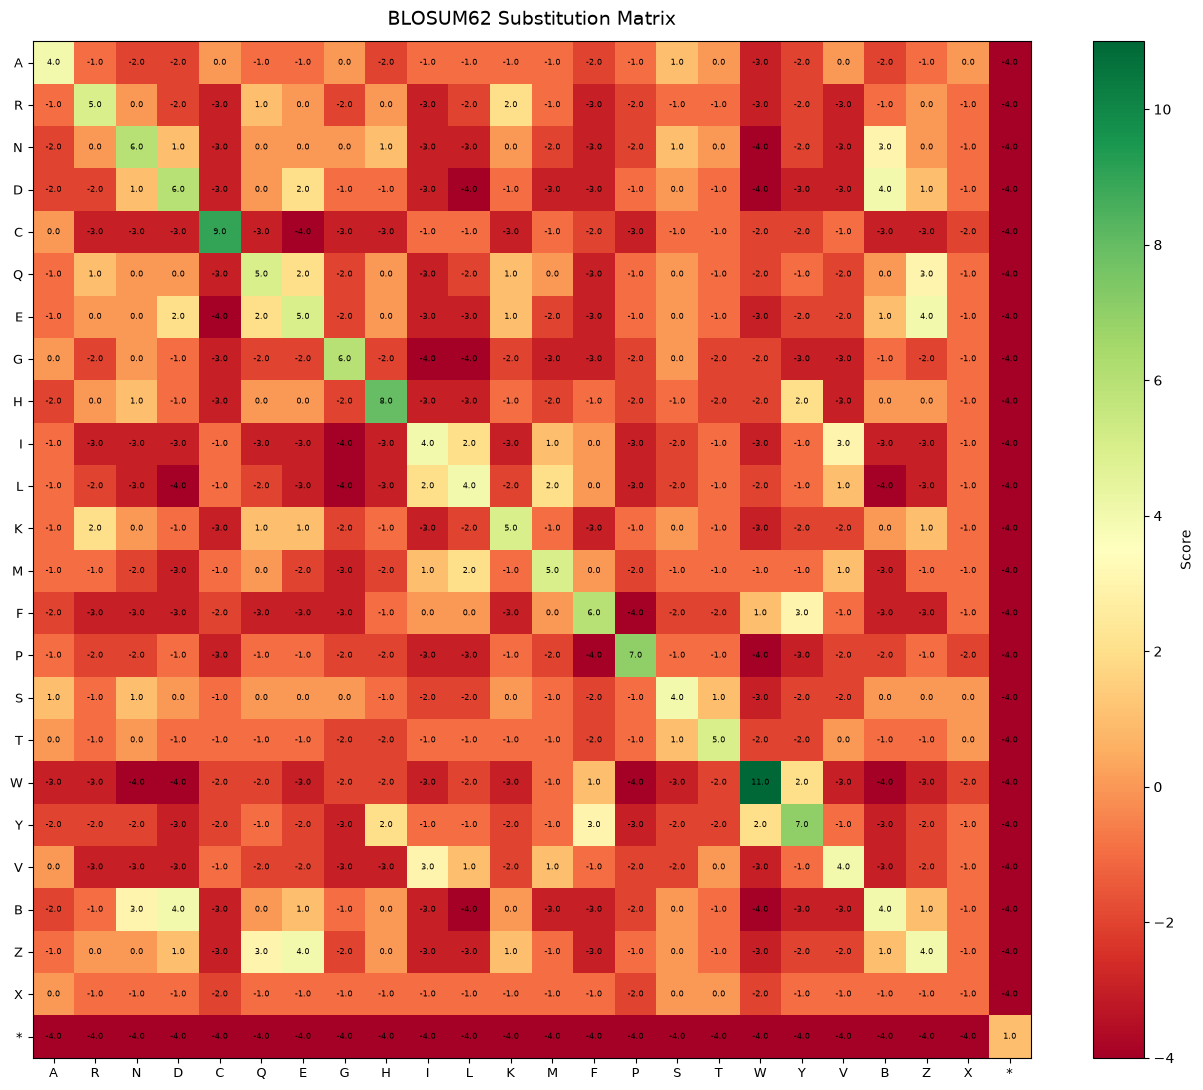

In [40]:
amino_acids  = list(blosum62.alphabet)
matrix_array = np.array([[blosum62[a, b] for b in amino_acids] for a in amino_acids])

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(matrix_array, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(amino_acids))); ax.set_xticklabels(amino_acids, fontsize=9)
ax.set_yticks(range(len(amino_acids))); ax.set_yticklabels(amino_acids, fontsize=9)
plt.colorbar(im, ax=ax, label="Score")
ax.set_title("BLOSUM62 Substitution Matrix", fontsize=14, pad=12)
for i in range(len(amino_acids)):
    for j in range(len(amino_acids)):
        ax.text(j, i, matrix_array[i, j], ha="center", va="center", fontsize=6)
plt.tight_layout()
plt.savefig("blosum62_heatmap.png", dpi=150)
plt.show()

> **Questions 4–5**
>
> 4. Identify a cluster of amino acids that score well against each other. What do they share chemically?
> 5. Which diagonal element (self-score) is highest? Why might that amino acid be the most "unique"?

**Your answers:**

4. 
5. 